# OOD-XML Distribution Report — Figure Generation

**Dataset:** 150 Elsevier ScienceDirect articles from `ood-xml/` directory (2025-2026).

Each cell generates one publication-ready figure. Toggle `FANCY = True` at the top for stylized versions.

In [1]:
# Cell 1: Imports, paths, and global config
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patheffects as pe
import numpy as np
from pathlib import Path
import os, warnings
warnings.filterwarnings("ignore")

# Optional imports
try:
    import seaborn as sns
    HAS_SNS = True
except ImportError:
    HAS_SNS = False

# Toggle: FANCY = True for stylized version, False for strict academic
FANCY = True

# Paths
OUT_DIR = Path("plots")
OUT_DIR.mkdir(exist_ok=True)

# Colorblind-safe Tol palette
C_BLUE       = "#4477AA"
C_VERMILLION = "#EE6677"
C_TEAL       = "#228833"
C_AMBER      = "#CCBB44"
C_PURPLE     = "#AA3377"
C_GRAY       = "#BBBBBB"
C_DARK_GRAY  = "#666666"

# Academic base style
def academic_style():
    return {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 11,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "axes.linewidth": 0.8,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": False,
        "legend.frameon": True,
        "legend.edgecolor": "black",
        "legend.fontsize": 8,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.facecolor": "white",
    }

def fancy_style():
    base = academic_style()
    base.update({
        "axes.facecolor": "#FAFBFD",
        "figure.facecolor": "#FAFBFD",
        "axes.grid": True,
        "grid.alpha": 0.3,
        "grid.linestyle": "--",
        "grid.color": "#AAAAAA",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.fancybox": True,
        "legend.shadow": True,
    })
    return base

def apply_style():
    style = fancy_style() if FANCY else academic_style()
    plt.rcParams.update(style)
    if HAS_SNS and FANCY:
        sns.set_palette("muted")

apply_style()

# Helper: add figure caption below the plot
def add_caption(fig, text, y=-0.02):
    fig.text(0.5, y, text, ha="center", va="top", fontsize=8,
             fontstyle="italic", wrap=True,
             transform=fig.transFigure)

# Helper: save figure
def save_fig(fig, name):
    suffix = "_fancy" if FANCY else ""
    path = OUT_DIR / f"{name}{suffix}.png"
    fig.savefig(path, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
    print(f"Saved: {path}")

print("Setup complete.")
print(f"  Style: {'FANCY' if FANCY else 'ACADEMIC'}")
print(f"  seaborn: {HAS_SNS}")

Setup complete.
  Style: FANCY
  seaborn: True


In [2]:
# Cell 2: OOD-XML data

# Top 15 journals (by count)
journal_data = [
    ("Biomedical Signal Processing and Control", 20),
    ("Computers in Biology and Medicine", 17),
    ("Computer Methods and Programs in Biomedicine", 11),
    ("Medical Image Analysis", 9),
    ("Computerized Medical Imaging and Graphics", 8),
    ("Array", 7),
    ("Engineering Applications of Artificial Intelligence", 7),
    ("Data in Brief", 5),
    ("Knowledge-Based Systems", 5),
    ("Machine Learning with Applications", 5),
    ("Applied Soft Computing", 4),
    ("Chaos, Solitons & Fractals", 4),
    ("Expert Systems with Applications", 4),
    ("Information Sciences", 4),
    ("Neural Networks", 3),
]
journal_labels = [j[0] for j in journal_data]
journal_counts = [j[1] for j in journal_data]

# Year distribution
year_data = {
    2025: 71,
    2026: 79,
}
years = list(year_data.keys())
year_counts = list(year_data.values())

print("Data loaded: 150 OOD articles from 45 unique journals.")

Data loaded: 150 OOD articles from 45 unique journals.


## Figure 1 — Top 15 Journals (OOD-XML)

Saved: plots\ood_fig1_top_journals_fancy.png


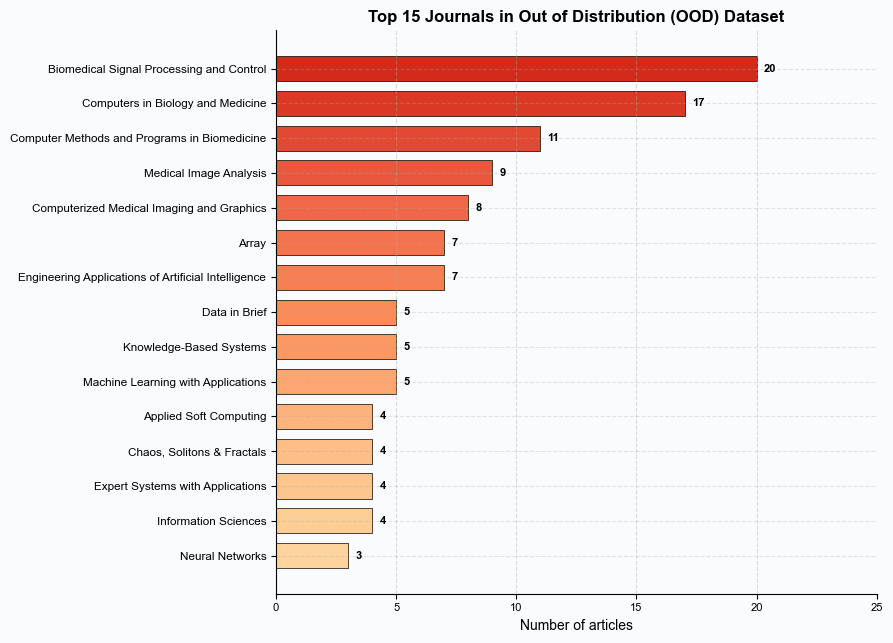

In [3]:
# Figure 1: Top 15 Journals - Horizontal Bar
apply_style()

fig, ax = plt.subplots(figsize=(9, 6.5))
y_pos = np.arange(len(journal_labels))

labels_r = journal_labels[::-1]
counts_r = journal_counts[::-1]

if FANCY:
    cmap = plt.cm.OrRd
    colors = [cmap(0.25 + 0.55 * i / len(counts_r)) for i in range(len(counts_r))]
else:
    colors = [C_DARK_GRAY] * len(counts_r)

bars = ax.barh(y_pos, counts_r, height=0.72, color=colors,
               edgecolor="black", linewidth=0.5)

for bar, val in zip(bars, counts_r):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", ha="left", fontsize=8, fontweight="bold")

ax.set_yticks(y_pos)
ax.set_yticklabels(labels_r, fontsize=8.5)
ax.set_xlabel("Number of articles")
ax.set_xlim(0, 25)
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax.grid(axis="x", linestyle="--", alpha=0.4, color="#AAAAAA")
ax.set_title("Top 15 Journals in Out of Distribution (OOD) Dataset", fontsize=12, fontweight="bold")

# add_caption(fig,
#     'Fig. 1. Top 15 publication venues in OOD dataset (out of 45 unique journals, n = 150). '
#     'Biomedical Signal Processing and Control and Computers in Biology and Medicine lead, '
#     'reflecting focus on applied AI/ML in medical domains.',
#     y=-0.06)

plt.tight_layout()
save_fig(fig, "ood_fig1_top_journals")
plt.show()

## Figure 2 — Publication Year Distribution (OOD-XML)

Saved: ood_fig2_year_distribution_fancy.png


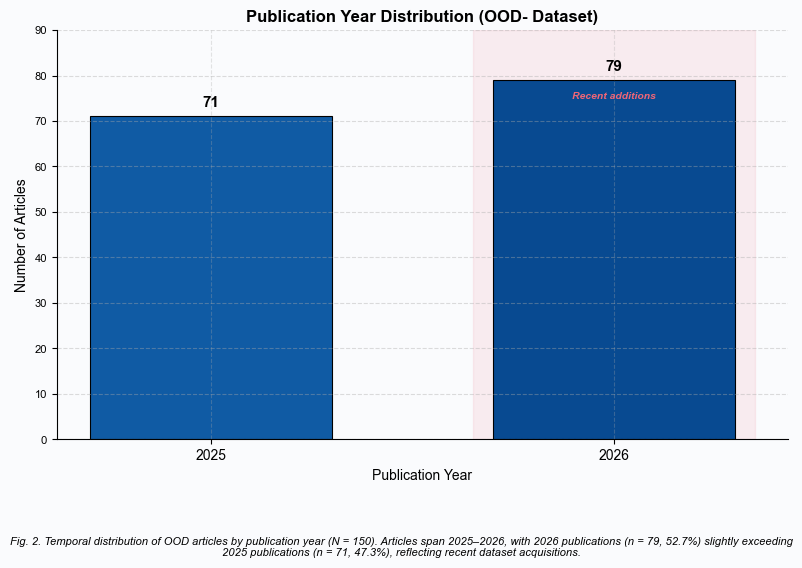

In [7]:
# Figure 2: Year Distribution - Vertical Bar
apply_style()

fig, ax = plt.subplots(figsize=(8, 5))
x_pos = np.arange(len(years))

if FANCY:
    max_c = max(year_counts)
    cmap = plt.cm.Blues
    colors = [cmap(0.25 + 0.65 * c / max_c) for c in year_counts]
else:
    colors = [C_BLUE] * len(years)

bars = ax.bar(x_pos, year_counts, width=0.6, color=colors,
              edgecolor="black", linewidth=0.8)

# Label each bar with count
for bar, val in zip(bars, year_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            str(val), ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_xticks(x_pos)
ax.set_xticklabels([str(y) for y in years], fontsize=10)
ax.set_xlabel("Publication Year")
ax.set_ylabel("Number of Articles")
ax.set_ylim(0, 90)
ax.yaxis.set_major_locator(mticker.MultipleLocator(10))
ax.grid(axis="y", linestyle="--", alpha=0.4, color="#AAAAAA")
ax.set_title("Publication Year Distribution (OOD- Dataset)", fontsize=12, fontweight="bold")

# FANCY: highlight 2026
if FANCY:
    ax.axvspan(x_pos[-1] - 0.35, x_pos[-1] + 0.35,
               alpha=0.1, color=C_VERMILLION, zorder=0)
    ax.text(x_pos[-1], 75, "Recent additions", ha="center", fontsize=7.5,
            color=C_VERMILLION, fontstyle="italic", fontweight="bold")

add_caption(fig,
    'Fig. 2. Temporal distribution of OOD articles by publication year (N = 150). '
    'Articles span 2025–2026, with 2026 publications (n = 79, 52.7%) slightly exceeding '
    '2025 publications (n = 71, 47.3%), reflecting recent dataset acquisitions.',
    y=-0.08)

plt.tight_layout()
save_fig(fig, "ood_fig2_year_distribution")
plt.show()

---
## Re-generate in FANCY mode

Set `FANCY = True` in Cell 1 and **Restart & Run All** to produce the stylized versions.
Both versions are saved with distinct filenames (`_fancy` suffix).